<a href="https://www.kaggle.com/code/elifduman/medical-cost-personal-linear-regression?scriptVersionId=346075428" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv")

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:
data.shape

(1338, 7)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
data["sex"].value_counts().unique

<bound method Series.unique of sex
male      676
female    662
Name: count, dtype: int64>

In [11]:
data["sex"]=data["sex"].map({"male":0,"female":1})

In [12]:
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,0,30.97,3,no,northwest,10600.5483
1334,18,1,31.92,0,no,northeast,2205.9808
1335,18,1,36.85,0,no,southeast,1629.8335
1336,21,1,25.80,0,no,southwest,2007.9450
1337,61,1,29.07,0,yes,northwest,29141.3603


In [13]:
data["smoker"]=data["smoker"].map({"no":0,"yes":1})

In [14]:
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,0,30.97,3,0,northwest,10600.5483
1334,18,1,31.92,0,0,northeast,2205.9808
1335,18,1,36.85,0,0,southeast,1629.8335
1336,21,1,25.80,0,0,southwest,2007.9450
1337,61,1,29.07,0,1,northwest,29141.3603


In [15]:
data["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

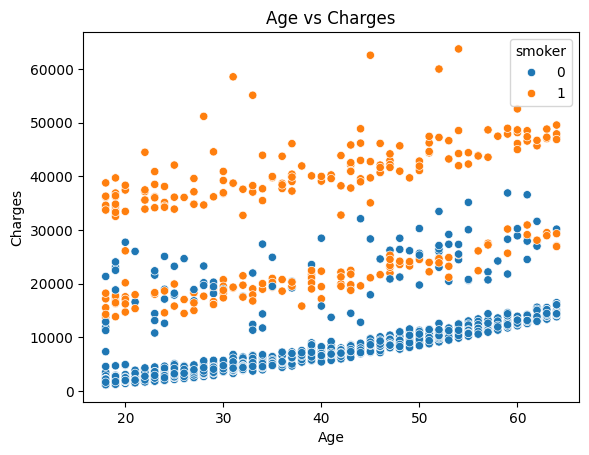

In [16]:
sns.scatterplot(x="age",y="charges",hue="smoker",data=data)
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.show()

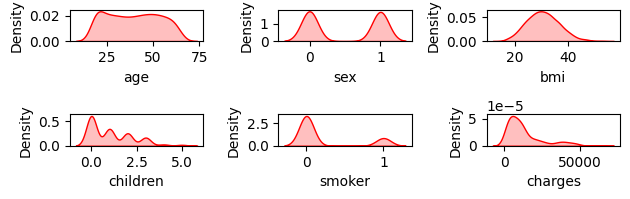

In [17]:
numerical_features=[feature for feature in data.columns if data[feature].dtype !="O"]
categorical_features=[feature for feature in data.columns if data[feature].dtype == "O"]

for i in range(0,len(numerical_features)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=data[numerical_features[i]],fill=True,color="r")
    plt.xlabel(numerical_features[i])
    plt.tight_layout()
plt.show()

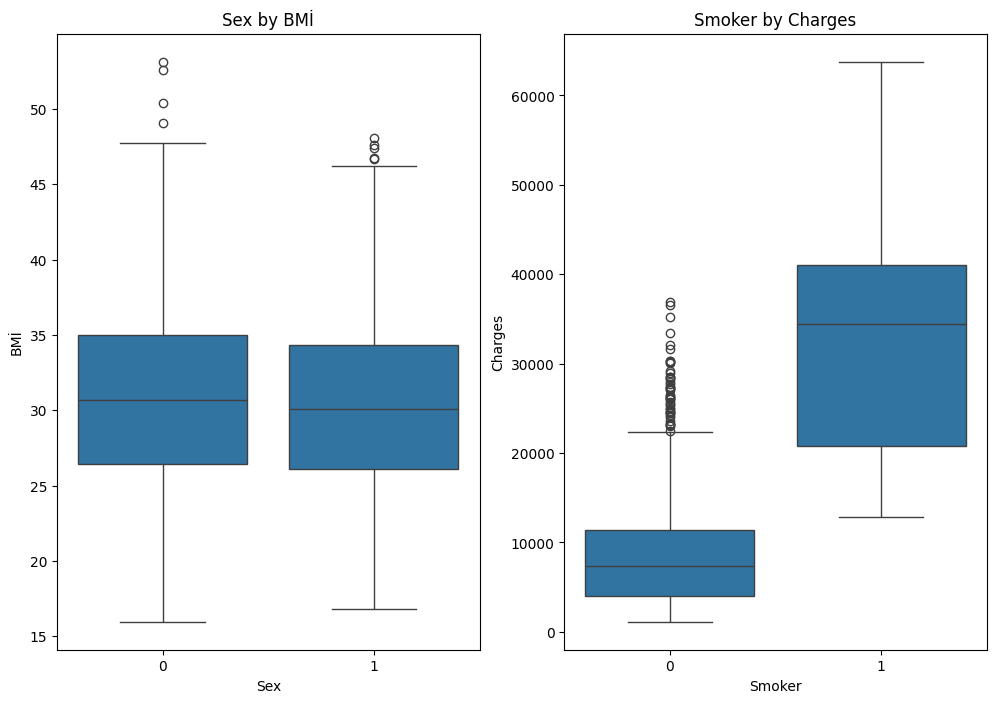

In [18]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.boxplot(x="sex",y="bmi",data=data)
plt.title("Sex by BMİ")
plt.xlabel("Sex")
plt.ylabel("BMİ")
plt.subplot(1,2,2)
sns.boxplot(x="smoker",y="charges",data=data)
plt.title("Smoker by Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

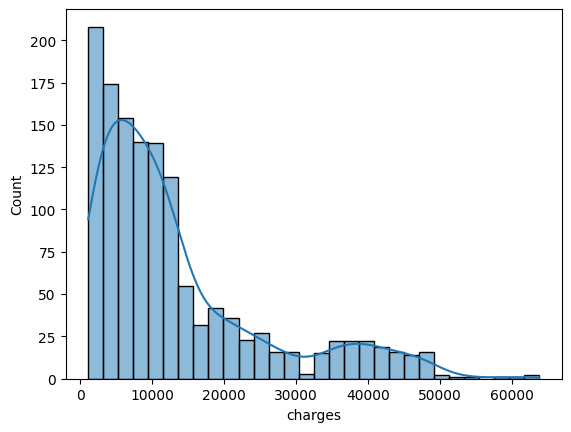

In [19]:
sns.histplot(data=data["charges"],kde=True)
plt.show()

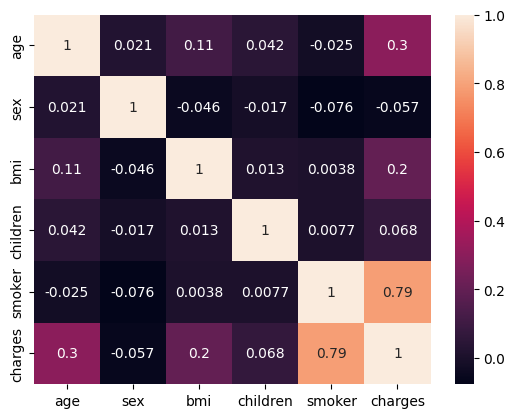

In [20]:
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.show()

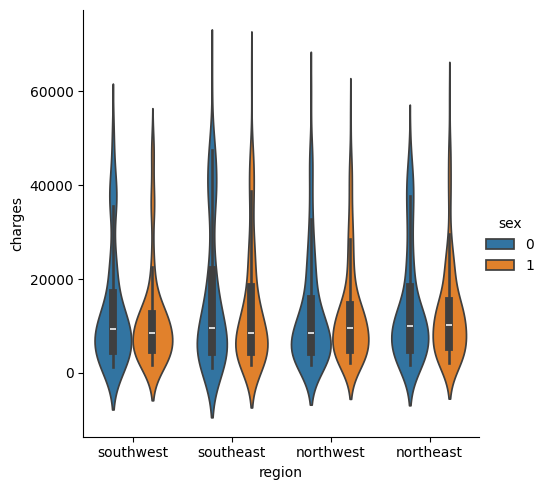

In [21]:
sns.catplot(x="region",y="charges",hue="sex",kind="violin",data=data)
plt.show()

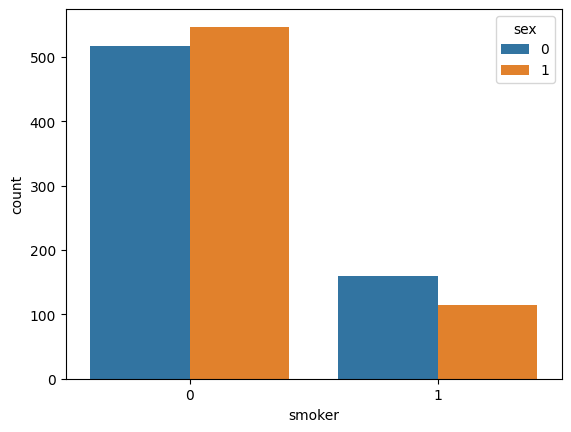

In [22]:
sns.countplot(x="smoker",hue="sex",data=data)
plt.show()

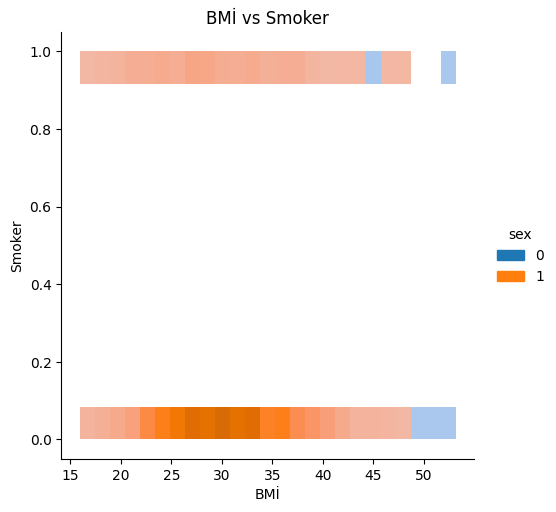

In [23]:
sns.displot(x="bmi",y="smoker",hue="sex",data=data)
plt.title("BMİ vs Smoker")
plt.xlabel("BMİ")
plt.ylabel("Smoker")
plt.show()

In [24]:
#ONE-HOT ENCODİNG
print(data["region"].value_counts())
data=pd.get_dummies(data,columns=["region"],drop_first=True)
print(data.columns)

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.8 KB
